# PHY 480 Final Project
### &#9989; Andrew Koren
#### &#9989; 5/1/25

# ___PARTICLES GO BRRR___ <br>
## ___simulating more molecules on a cpu___

## Background and Motivation

In class, we've shown how to implement molecular dynamics with symplectic time stepping and discussed how to couple to a thermostat as a step towards working in the canonical ensemble. These simulations can be valuable as means to better understand statistical physics and the dynamics that come as a result of many simple potentials interacting together. 

I'm currently working on an honors project for PHY 410 where I use simulation to analyze a system and compare to a similar analytical system. I've enjoyed the overlap between these two classes, especially being able to apply computational methods to not only analyze but also visualize physical systems we'd otherwise only see as equations with long chains of variables and differentials.  

With visualization and simulation in mind, I've decided to learn more about computational methods that would allow me to observe larger and more complex systems. In particular, I'm investigating assumptions that can be made to improve molecular dynamics per-particle scaling laws. I want to be able to run simulations with thousands of particles without scaling up hardware or switching my implementation to gpu. 

Since this is a rather broad and rich goal, I've read up and picked out one particular limit to particle scaling: all-to-all long range interactions. As I mention in __Methodology__, a primary slowdown of my code comes from calculating distances between particles, even though most particles are too far to actually have an impact on eachother. 

### Outline:

1. Establishing Molecular Dynamics Simulation
2. Execution time and scaling
3. Implementing The Cell List Algorithm
4. Results (w/basic parallelization)
5. Discussion and Conclusion
6. Aside: my animation class

## Methodology

1. Molecular Dynamics.

The basic code for MD is the same as our in-class assignments. Below is a snippet of the naieve implementation, which measures distance between all particles before calculating forces. To avoid bloating the notebook, functions are defined in .py files and imported. If you're curious, you can investigate these to see how each function is implemented.

In [ ]:
# 1. Molecular Dynamics
from _1_molecular_dynamics import *
import numpy as np

### Simulation Parameters ###

# structure
dim = 3
radius = (2)**(1/6)
rcut = 2.5 # field limits
lbox = np.array( [15.0,15.0,15.0] )
PBC = True

# initial conditions
N = 200
Temp = 0.2

# allocate arrays
r = np.zeros( (N,dim) )
v = np.zeros( (N,dim) )
f = np.zeros( (N,dim) )
masses = np.full( N, 1 )

# simulation parameters
sim_fps = 30 
dt = 1/sim_fps

runtime = 20 
skiptime = 10 # even out from initial conditions

In [ ]:
### Run Simulation ###

Nsim = int(runtime*sim_fps) 
Ninner = 1
frames = Nsim 

skipframes = int(skiptime*sim_fps)

easy_initial_r( lbox, r, min_dist=radius/4 )
initial_v( lbox, v, Temp, masses)

def run_simulation(r, v, f, masses, Nsim, PBC, lbox, dt, rcut, skipframes=0, Ninner=1):

    r_storage = np.zeros([Nsim,*r.shape])
    f_storage = np.zeros([Nsim,*f.shape])

    frame = 0
    for i in range(Nsim+skipframes):
        # inner loop
        for j in range(Ninner):
            # propagate velocities by dt/2
            update_v(dt/2, v, f, masses)

            # propagate positions r by dt
            update_r(dt, r, v)
            # apply boundary conditions
            [boundary_wall, boundary_periodic][PBC]( lbox, r, v )

            # compute forces
            forces_lj( lbox, r, f, rcut, PBC)

            # propagate velocities by dt/2
            update_v(dt/2, v, f, masses)

        # record evolution
        if i >= skipframes:
            r_storage[frame] = r
            f_storage[frame] = f
            frame += 1

    return r_storage, f_storage

r_storage, f_storage = run_simulation(r, v, f, masses, Nsim, PBC, lbox, dt, rcut, skipframes, Ninner)

This code is structured the same as in-class code, using symplectic integration to bring particles to move particles. If you've chosen to actually look behind the scences, you'll notice that I am using @njit decorators for my functions. This compiles code to run much faster due to various improvements, but comes at the cost of some functionality since it uses a static rather than dynamic type system. I've neglected to measure kinetic/potential energy since we're system-agnostic and are more concerned with execution time in general.

Using the stored frame data, we can make an animated plot of the particles

In [ ]:
from animator import ParticleAnimator
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
#%matplotlib widget

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
bounding = 0.5

plt.title(f'N={N} particles in LJ Fluid')

if PBC:
    ax.set_xlim(0+bounding, lbox[0]-bounding)
    ax.set_ylim(0+bounding, lbox[1]-bounding)
    ax.set_zlim(0+bounding, lbox[2]-bounding)
else:
    ax.set_xlim(0, lbox[0])
    ax.set_ylim(0, lbox[1])
    ax.set_zlim(0, lbox[2])

max_force_norm = np.max(np.linalg.norm(f_storage, axis=2))

forces = f_storage[0]
force_norms = np.linalg.norm(forces, axis=1)  # Correct axis for norm calculation
initial_colors = force_norms / max_force_norm

scat = ax.scatter(r_storage[0, :, 0], r_storage[0, :, 1], r_storage[0, :, 2],
    s=radius**2/(lbox[0]*lbox[1]*lbox[2])*4e5/8,
    c=initial_colors,
    cmap='gnuplot2', vmin=0, vmax=1)

cbar = fig.colorbar(scat, ax=ax, shrink=0.6, aspect=20, label='Force Magnitude')

def animate(ax, i):
    scat._offsets3d = (r_storage[i, :, 0], r_storage[i, :, 1], r_storage[i, :, 2])

    forces = f_storage[i]
    force_norms = np.linalg.norm(forces, axis=1)  # Correct axis for norm calculation
    force_norms_normalized = force_norms / max_force_norm

    scat.set_array(force_norms_normalized) # updates the color per point
    return scat

plt.tight_layout()

Depending on what you're using to run this journal, you should be able to scroll around in 3D. You can try the `%matplotlib widget` shell magic if it doesn't work by default, just uncomment it in line 4 above. 

For animation, I am using PillowWriter since more devices have it. You can also try FFMpegWriter by setting `Pillow = False`, which creates videos rather than gifs, but it doesn't come pre-installed on every device

In [ ]:
from animator import ParticleAnimator

Pillow = True

if Pillow:
    from matplotlib.animation import PillowWriter
    writer = PillowWriter
    filename = '3danim.gif'
else:
    from matplotlib.animation import FFMpegWriter
    writer = FFMpegWriter
    filename = '3danim.mp4'

display_fps = 30

anim = ParticleAnimator(fig, writer, filename)
anim.set_display(display_fps, runtime)
frame_data = anim.generate_frame_data([i for i in range(len(r_storage))], update_fps=30)
anim.animate_ax(ax, animate, frame_data)
anim.make_animation()
anim.display()

3D animation isn't perfect, especially since points are 'fake 3D', simply being resized and redrawn based off distance from the camera rather than rendered 3D sphreres, but the force magnitude coloring should help show when two particles approach and deflect off eachother.



2. Execution time and scaling

The above plot is for $N=200$ particles, but what if we use more? From my experience, simulation times tend to get quite long for $N\rightarrow 800$ particles. We should quantify and observe the quadratic scaling law of all-to-all calculations.

In [ ]:
from _2_execution_time import run_simulation_tracking, plot_frametimes, plot_scaling_chart

_, _, segment_times = run_simulation_tracking(r, v, f, masses, Nsim, PBC, lbox, dt, rcut, skipframes, Ninner)
plot_frametimes(segment_times)

This timing is the same `run_simulation` function as before, only with the added ability to measure the time between each step in the symplectic integrator (not including time spent saving data). The area under these curves is actually a near approximation of total simulation time. We clearly observe that force calculations take much longer than all other steps for $N=200$ (assuming the above cell was run sequentially to the previous). To observe scaling of force calculation time with particle count, we can simply measure how this time vares with the number of particles used.

In [ ]:
meta_segment_times = []
for N in [100,200,300,400,500,600,700,800]:
    r = np.zeros( (N,dim) )
    v = np.zeros( (N,dim) )
    f = np.zeros( (N,dim) )
    masses = np.full( N, 1 )

    
    easy_initial_r( lbox, r, min_dist=radius/4 )
    initial_v( lbox, v, Temp, masses)

    _, _, segment_times = run_simulation_tracking(r, v, f, masses, Nsim, PBC, lbox, dt, rcut, skipframes, Ninner)
    meta_segment_times.append((N, segment_times))

plot_scaling_chart(meta_segment_times)
plt.legend()

To save time plotting, I've applied a curve fit using desmos.

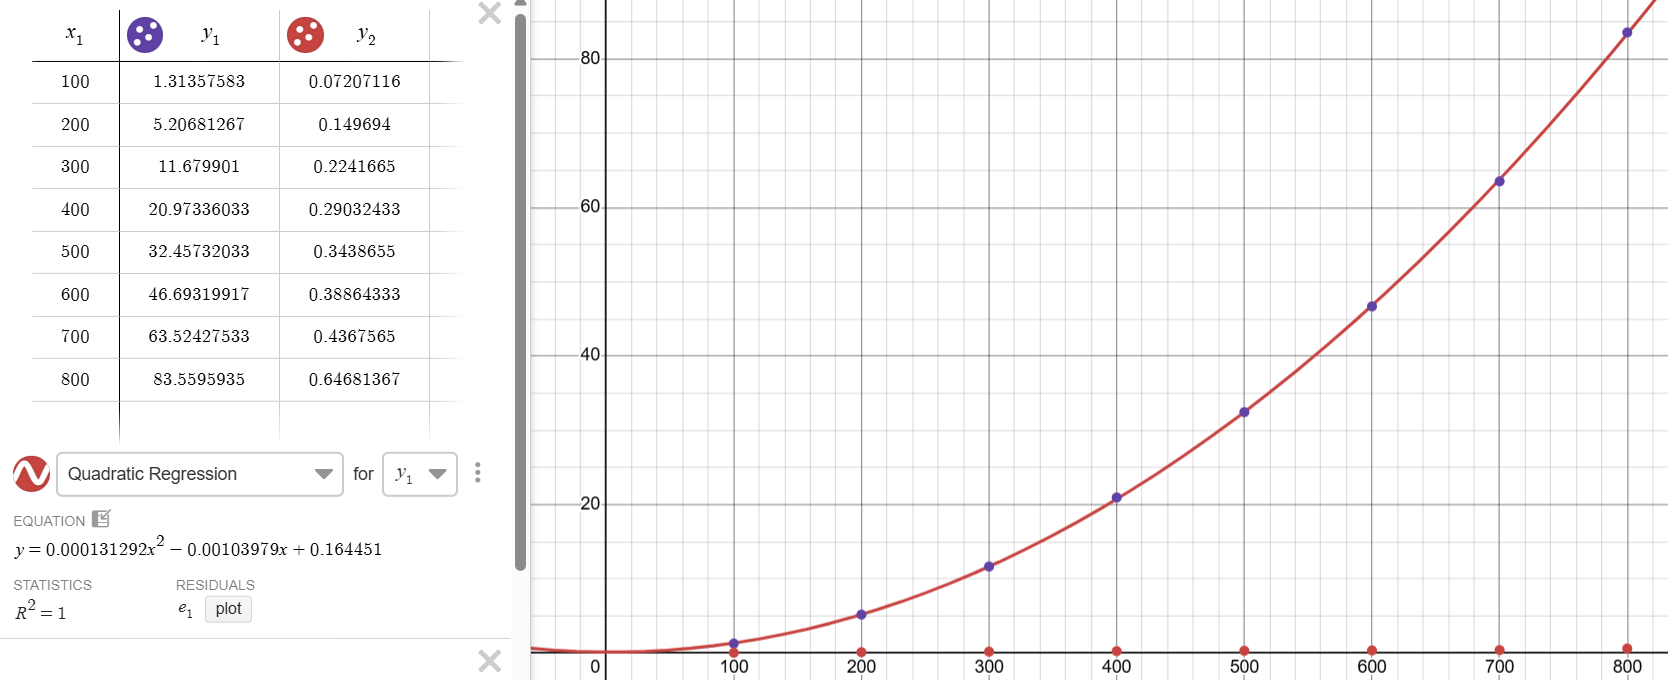

Yes, the rest of the code is linear with number of particles, thank you for asking.

So, clearly any improvement which disrupts all-to-all computing without significant overhead would speed up computation. We'll use these results as a benchmark for our cpu-saving method

3. Implementing The Cell List Algorithm

The center of this project is the cell list algorithm for determining whether particle distances are within `rcut` efficiently. The code is a bit dense, but here's the overview:

`setup_linked_list` creates the cell list and uses a linked list to store particle data. Each cell is a sub-section of the entire `lbox` where each particle only checks if particles in it's cell and neighboring cells are within `rcut`. After computing how many cells there are, the static linked list data structure allows for quickly saving which particle is in which box.

The head can be indexed by cell indexing (`head[n]` for cell `n`), and returns the first particle in the linked list. The linked list then reveals all the other particles in the cell. Linked lists function similarly to dynamic python lists, only without needing dynamic memory, allowing for faster computation by our static compiler. forces_lj now draws neighbors from the cell list system.

This cell list allows for 500 particles to be simulated faster than 200 particles could be previously, and doesn't cost accuracy since it only drops distance measurements already greater than `rcut`

In [ ]:
from _3_cell_list import cl_forces_lj, compute_cell_sizes

n_cells, cell_size = compute_cell_sizes(lbox, rcut)

N = 500
r = np.zeros( (N,dim) )
v = np.zeros( (N,dim) )
f = np.zeros( (N,dim) )
masses = np.full( N, 1 )    
easy_initial_r( lbox, r, min_dist=radius/4 )
initial_v( lbox, v, Temp, masses)

r_storage, f_storage, segment_times = run_simulation_tracking(r, v, f, masses, Nsim, PBC, lbox, dt, rcut, skipframes, Ninner, forces_lj=cl_forces_lj)
plot_frametimes(segment_times)


## Results

Below, we plot average frame computation time for both all-to-all and cell-list distance calculations. Note that there are a total of 216 cells with the current choice of `rcut` and `lbox`.

In [ ]:
label_list = [('Standard Force Calculation', 'Standard other'), ('Cell-List Force Calculation', 'Cell-List Other')]

for i, forces in enumerate((forces_lj, cl_forces_lj)):
    meta_segment_times = []
    for N in [100,200, 300,400,500,600,700,800]:
        masses = np.full( N, 1 )
        r = np.zeros( (N,dim) )
        v = np.zeros( (N,dim) )
        f = np.zeros( (N,dim) )
        easy_initial_r( lbox, r, min_dist=radius/4 )
        initial_v( lbox, v, Temp, masses)
        _, _, segment_times = run_simulation_tracking(r, v, f, masses, Nsim, PBC, lbox, dt, rcut, skipframes, Ninner, forces_lj=forces)
        meta_segment_times.append((N, segment_times))
    plot_scaling_chart(meta_segment_times, label_list[i])

plt.legend()
    

This is an incredible improvment! We should check if linearity sticks around at higher `N` values

In [ ]:

meta_segment_times = []
for N in [100,200,300,400,600,800,1000,1200,1300,1600,1800,2000]:
    masses = np.full( N, 1 )
    r = np.zeros( (N,dim) )
    v = np.zeros( (N,dim) )
    f = np.zeros( (N,dim) )
    easy_initial_r( lbox, r, min_dist=radius/4 )
    initial_v( lbox, v, Temp, masses)
    r_storage, f_storage, segment_times = run_simulation_tracking(r, v, f, masses, Nsim, PBC, lbox, dt, rcut, skipframes, Ninner, forces_lj=cl_forces_lj)
    meta_segment_times.append((N, segment_times))
plot_scaling_chart(meta_segment_times)

plt.legend()
    

Looks like the quadratic time never actually went away, it was just stretched out. 

For reference, here's our simulation plotted with 10x the number of particles as previously.

In [ ]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
bounding = 0.5

plt.title(f'N={N} particles in LJ Fluid')

if PBC:
    ax.set_xlim(0+bounding, lbox[0]-bounding)
    ax.set_ylim(0+bounding, lbox[1]-bounding)
    ax.set_zlim(0+bounding, lbox[2]-bounding)
else:
    ax.set_xlim(0, lbox[0])
    ax.set_ylim(0, lbox[1])
    ax.set_zlim(0, lbox[2])

max_force_norm = np.max(np.linalg.norm(f_storage, axis=2))

forces = f_storage[0]
force_norms = np.linalg.norm(forces, axis=1)  # Correct axis for norm calculation
initial_colors = force_norms / max_force_norm

scat = ax.scatter(r_storage[0, :, 0], r_storage[0, :, 1], r_storage[0, :, 2],
    s=radius**2/(lbox[0]*lbox[1]*lbox[2])*4e5/8,
    c=initial_colors,
    cmap='gnuplot2', vmin=0, vmax=1)

cbar = fig.colorbar(scat, ax=ax, shrink=0.6, aspect=20, label='Force Magnitude')

def animate(ax, i):
    scat._offsets3d = (r_storage[i, :, 0], r_storage[i, :, 1], r_storage[i, :, 2])

    forces = f_storage[i]
    force_norms = np.linalg.norm(forces, axis=1)  # Correct axis for norm calculation
    force_norms_normalized = force_norms / max_force_norm

    scat.set_array(force_norms_normalized) # updates the color per point
    return scat

plt.tight_layout()

if Pillow:
    from matplotlib.animation import PillowWriter
    writer = PillowWriter
    filename = '3danim_10x.gif'
else:
    from matplotlib.animation import FFMpegWriter
    writer = FFMpegWriter
    filename = '3danim_10x.mp4'

display_fps = 30

anim = ParticleAnimator(fig, writer, filename)
anim.set_display(display_fps, runtime)
frame_data = anim.generate_frame_data([i for i in range(len(r_storage))], update_fps=30)
anim.animate_ax(ax, animate, frame_data)
anim.make_animation()
anim.display()

Numba also has a simple method of parallelizing code, which has a similar effect. In the case of our force calculation, this is a single line change in our `cl_forces_lj` function (convert `range` to `numba.prange`), and allows for multiple cpu cores to calculate and contribute forces simultaneously, since there is no chance two cpu threads will recompute the same force vector simultaneously. This can allow us to make a plot with insane numbers of particles

In [ ]:
from _3_cell_list import cl_forces_lj_parallel


#meta_segment_times = []
for N in [6000,7000,8000,9000,10000]:#[1000,2000,3000,4000,5000,6000,7000,8000,9000,10000]:
    masses = np.full( N, 1 )
    r = np.zeros( (N,dim) )
    v = np.zeros( (N,dim) )
    f = np.zeros( (N,dim) )
    easy_initial_r( lbox, r, min_dist=radius/4 )
    initial_v( lbox, v, Temp, masses)
    r_storage, f_storage, segment_times = run_simulation_tracking(r, v, f, masses, Nsim, PBC, lbox, dt, rcut, skipframes, Ninner, forces_lj=cl_forces_lj_parallel)
    meta_segment_times.append((N, segment_times))
plot_scaling_chart(meta_segment_times)

plt.legend()

I'm running a 14-core laptop, and my CPU usage was at 100% while running. The combined cell-list/parallel processing allowed for calculating 6000 particles faster than 800 using all-to-all calculation. Note that for N=10k, even the linear portions of code are starting to take as longas N=300 standard calculation.

The resulting animation of 10000 particles is shown below.

In [ ]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
bounding = 0.5

plt.title(f'N={N} particles in LJ Fluid')

if PBC:
    ax.set_xlim(0+bounding, lbox[0]-bounding)
    ax.set_ylim(0+bounding, lbox[1]-bounding)
    ax.set_zlim(0+bounding, lbox[2]-bounding)
else:
    ax.set_xlim(0, lbox[0])
    ax.set_ylim(0, lbox[1])
    ax.set_zlim(0, lbox[2])

max_force_norm = np.max(np.linalg.norm(f_storage, axis=2))

forces = f_storage[0]
force_norms = np.linalg.norm(forces, axis=1)  # Correct axis for norm calculation
initial_colors = force_norms / max_force_norm

scat = ax.scatter(r_storage[0, :, 0], r_storage[0, :, 1], r_storage[0, :, 2],
    s=radius**2/(lbox[0]*lbox[1]*lbox[2])*4e5/8,
    c=initial_colors,
    cmap='gnuplot2', vmin=0, vmax=1)

cbar = fig.colorbar(scat, ax=ax, shrink=0.6, aspect=20, label='Force Magnitude')

def animate(ax, i):
    scat._offsets3d = (r_storage[i, :, 0], r_storage[i, :, 1], r_storage[i, :, 2])

    forces = f_storage[i]
    force_norms = np.linalg.norm(forces, axis=1)  # Correct axis for norm calculation
    force_norms_normalized = force_norms / max_force_norm

    scat.set_array(force_norms_normalized) # updates the color per point
    return scat

plt.tight_layout()

if Pillow:
    from matplotlib.animation import PillowWriter
    writer = PillowWriter
    filename = '3danim_50x.gif'
else:
    from matplotlib.animation import FFMpegWriter
    writer = FFMpegWriter
    filename = '3danim_50x.mp4'

display_fps = 30

anim = ParticleAnimator(fig, writer, filename)
anim.set_display(display_fps, runtime)
frame_data = anim.generate_frame_data([i for i in range(len(r_storage))], update_fps=30)
anim.animate_ax(ax, animate, frame_data)
anim.make_animation()
anim.display()

## Discussion and Conclusion

It is clear that cell-list and parallelization together allow for many more particles to be simulated in the same amount of time, however the speedup never changes the complexity order of the problem. This makes sense if we think about what the two methods are doing. 

Cell-list decreases the space in which a particle must search for other particles that are within `rcut`. Instead of searching all of `lbox`, search is only done with the nearest cells. In three dimensions, there are 27 neighbor cells (including edges/corners), and for the above simulations we've used 216 subdivisions of `lbox`. In theory, this would result in only $\frac{27}{216}=\frac{1}{8}$ of the total space being searched, but 

The relative homogeneity of each cell means this effectively decreases the total number of particles to be searched by a factor of 8. If we entirely remove the overhead of rebuilding the linked list, this would be similar to running 1/8th as many particles with all-to-all evaluation, and practically we observe an approximate $2.5\text{x} -3\text{x}$ reduction in effective N relative to the standard method.

Similarly, we are able to compute N=1600 particles with parallel+cell list ~55ms/frame, the same time as N=1600 with a cell list alone, yielding about a $3.5\text{x}-4\text{x}$ relative improvement. The combined improvement of about $9\text{x}-12\text{x}$ is observed relative to the basic method.

Bonus visual: 15,000 particles for one minute!

In [ ]:
### Simulation Parameters ###

# structure
dim = 3
radius = (2)**(1/6)
rcut = 2.5 # field limits
lbox = np.array( [15.0,15.0,15.0] )
PBC = True

# initial conditions
N = 15000
Temp = 0.2

# allocate arrays
r = np.zeros( (N,dim) )
v = np.zeros( (N,dim) )
f = np.zeros( (N,dim) )
masses = np.full( N, 1 )

# simulation parameters
sim_fps = 30 
dt = 1/sim_fps

runtime = 60

Nsim = int(runtime*sim_fps) 
Ninner = 1
frames = Nsim 
skipframes = int(skiptime*sim_fps)


easy_initial_r( lbox, r, min_dist=radius/4 )
initial_v( lbox, v, Temp, masses)
r_storage, f_storage, segment_times = run_simulation_tracking(r, v, f, masses, Nsim, PBC, lbox, dt, rcut, skipframes, Ninner, forces_lj=cl_forces_lj_parallel)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
bounding = 0.5

plt.title(f'N={N} particles in LJ Fluid')

if PBC:
    ax.set_xlim(0+bounding, lbox[0]-bounding)
    ax.set_ylim(0+bounding, lbox[1]-bounding)
    ax.set_zlim(0+bounding, lbox[2]-bounding)
else:
    ax.set_xlim(0, lbox[0])
    ax.set_ylim(0, lbox[1])
    ax.set_zlim(0, lbox[2])

max_force_norm = np.max(np.linalg.norm(f_storage, axis=2))

forces = f_storage[0]
force_norms = np.linalg.norm(forces, axis=1)  # Correct axis for norm calculation
initial_colors = force_norms / max_force_norm

scat = ax.scatter(r_storage[0, :, 0], r_storage[0, :, 1], r_storage[0, :, 2],
    s=radius**2/(lbox[0]*lbox[1]*lbox[2])*4e5/8,
    c=initial_colors,
    cmap='gnuplot2', vmin=0, vmax=1)

cbar = fig.colorbar(scat, ax=ax, shrink=0.6, aspect=20, label='Force Magnitude')

def animate(ax, i):
    scat._offsets3d = (r_storage[i, :, 0], r_storage[i, :, 1], r_storage[i, :, 2])

    forces = f_storage[i]
    force_norms = np.linalg.norm(forces, axis=1)  # Correct axis for norm calculation
    force_norms_normalized = force_norms / max_force_norm

    scat.set_array(force_norms_normalized) # updates the color per point
    return scat

plt.tight_layout()

Pillow = False

if Pillow:
    from matplotlib.animation import PillowWriter
    writer = PillowWriter
    filename = 'big1.gif'
else:
    from matplotlib.animation import FFMpegWriter
    writer = FFMpegWriter
    filename = 'big1.mp4'

display_fps = 30

anim = ParticleAnimator(fig, writer, filename)
anim.set_display(display_fps, runtime)
frame_data = anim.generate_frame_data([i for i in range(len(r_storage))], update_fps=30)
anim.animate_ax(ax, animate, frame_data)
anim.make_animation()
anim.display()

### References

1. Frenkel, D. & Smit, B. Understanding Molecular Simulation: From Algorithms to Applications. (Academic Press, San Diego, 2001).
2. Deepseek AI (used for `get_neighbors` function and suggested cpu multithreading using `numba.prange`)